In [1]:
from utility import load_test_results, architecture_stats, sample_image

from NeuralNetwork import NeuralNetwork, torch

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.min_rows', 5000)
pd.set_option('display.max_rows', 5000)

In [2]:
classifiers_dict, all_results = load_test_results("Classifier_3")

In [3]:
classifiers_dict

{0: "Classifier_3 (n_neurons_molt_factor=2, do_dropout=['Conv2'])",
 1: "Classifier_3 (n_neurons_molt_factor=1, do_dropout=['Conv2', 'Conv3', 'FC1'])",
 2: 'Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=[])',
 3: "Classifier_3 (n_neurons_molt_factor=1, do_dropout=['Conv3'])",
 4: 'Classifier_3 (n_neurons_molt_factor=1, do_dropout=[])',
 5: "Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['FC1'])",
 6: "Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2', 'Conv3'])",
 7: "Classifier_3 (n_neurons_molt_factor=1, do_dropout=['Conv2'])",
 8: "Classifier_3 (n_neurons_molt_factor=1, do_dropout=['FC1'])",
 9: "Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv3'])",
 10: "Classifier_3 (n_neurons_molt_factor=2, do_dropout=['Conv3'])",
 11: "Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv3', 'FC1'])",
 12: "Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2', 'FC1'])",
 13: "Classifier_3 (n_neurons_molt_factor=1, do_dropout=['Conv3', 'FC1'])",
 14:

In [4]:
all_results.head(10)

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,optimizer,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
0,0,0,2.0,['Conv2'],AMSGrad,0.0005,32,5,0.00,0.020078,0.082985,10.274774
1,1,0,2.0,['Conv2'],AMSGrad,0.0005,32,5,0.25,0.020078,0.082584,5.663384
2,2,0,2.0,['Conv2'],AMSGrad,0.0005,32,5,0.50,0.020078,0.082888,6.735712
3,3,0,2.0,['Conv2'],AMSGrad,0.0005,32,5,0.75,0.020078,0.082331,31.197771
4,4,0,2.0,['Conv2'],AMSGrad,0.0005,32,10,0.00,0.020078,0.082214,8.450551
5,5,0,2.0,['Conv2'],AMSGrad,0.0005,32,10,0.25,0.020078,0.082479,10.368641
6,6,0,2.0,['Conv2'],AMSGrad,0.0005,32,10,0.50,0.020078,0.082609,12.337944
7,7,0,2.0,['Conv2'],AMSGrad,0.0005,32,10,0.75,0.020078,0.082693,14.279868
8,8,0,2.0,['Conv2'],AMSGrad,0.0005,32,15,0.00,0.020078,0.082699,12.273641
9,9,0,2.0,['Conv2'],AMSGrad,0.0005,32,15,0.25,0.020078,0.082577,15.146993


In [5]:
all_results.sort_values(by=['test_accuracies'], ascending=False).head(10)

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,optimizer,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
11101,639,17,1.0,"['Conv2', 'FC1']",ADAM,0.000001,512,20,0.75,1.0,0.041280,13.768896
10310,488,16,1.0,"['Conv2', 'Conv3']",ADAM,0.000010,32,15,0.00,1.0,0.081682,16.174489
10324,502,16,1.0,"['Conv2', 'Conv3']",ADAM,0.000010,64,10,0.50,1.0,0.058661,8.932671
10323,501,16,1.0,"['Conv2', 'Conv3']",ADAM,0.000010,64,10,0.25,1.0,0.058491,7.415842
10322,500,16,1.0,"['Conv2', 'Conv3']",ADAM,0.000010,64,10,0.00,1.0,0.058472,9.407550
10321,499,16,1.0,"['Conv2', 'Conv3']",ADAM,0.000010,64,5,0.75,1.0,0.058599,5.764244
10320,498,16,1.0,"['Conv2', 'Conv3']",ADAM,0.000010,64,5,0.50,1.0,0.058757,5.031274
10319,497,16,1.0,"['Conv2', 'Conv3']",ADAM,0.000010,64,5,0.25,1.0,0.058972,4.806295
10318,496,16,1.0,"['Conv2', 'Conv3']",ADAM,0.000010,64,5,0.00,1.0,0.058999,13.772312
7168,546,11,0.6,"['Conv3', 'FC1']",ADAM,0.000010,512,5,0.50,1.0,0.041255,3.392645


In [6]:
n_high_accuracy_architectures = len(all_results[all_results["test_accuracies"]==all_results["test_accuracies"].max()])
n_high_accuracy_architectures

1086

In [7]:
high_accuracy_architectures = all_results.sort_values(by=['test_accuracies'], ascending=False).head(n_high_accuracy_architectures)["architecture_id"].unique()
high_accuracy_architectures

array([17, 16, 11, 12,  1, 15, 14,  6,  7])

In [8]:
for model in high_accuracy_architectures:
    architecture_stats(all_results, classifiers_dict, model)

Stats for architecture: Classifier_3 (n_neurons_molt_factor=1, do_dropout=['Conv2', 'FC1']) (id: 17)
mean accuracy: 0.9991 with standard error: 0.0016

worst accuracy: 0.9849 with hyperparameters:
test_id                          2
optimizer                  AMSGrad
lr                          0.0005
batch_size                      32
patience                         5
data_augmentation_perc         0.5
test_times                 0.08193
train_times               6.693833
Name: 10464, dtype: object 

best accuracy: 1.0000 with hyperparameters:
test_id                         52
optimizer                  AMSGrad
lr                          0.0005
batch_size                     256
patience                        10
data_augmentation_perc         0.0
test_times                0.043919
train_times               5.811596
Name: 10514, dtype: object 

Stats for architecture: Classifier_3 (n_neurons_molt_factor=1, do_dropout=['Conv2', 'Conv3']) (id: 16)
mean accuracy: 0.9996 with standard er

Loaded model: Classifier_3 (n_neurons_molt_factor=1, do_dropout=['Conv2', 'FC1'])_test_639


Architecture:
name: Classifier_3 (n_neurons_molt_factor=1.0, do_dropout=['Conv2', 'FC1'])
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 32, 12, 12]          --
|    └─Conv2d: 2-1                       [-1, 32, 24, 24]          832
|    └─MaxPool2d: 2-2                    [-1, 32, 12, 12]          --
|    └─ReLU: 2-3                         [-1, 32, 12, 12]          --
├─Sequential: 1-2                        [-1, 64, 4, 4]            --
|    └─Conv2d: 2-4                       [-1, 64, 8, 8]            51,264
|    └─MaxPool2d: 2-5                    [-1, 64, 4, 4]            --
|    └─ReLU: 2-6                         [-1, 64, 4, 4]            --
|    └─Dropout: 2-7                      [-1, 64, 4, 4]            --
├─Sequential: 1-3                        [-1, 128, 1, 1]           --
|    └─Conv2d: 2-8                   

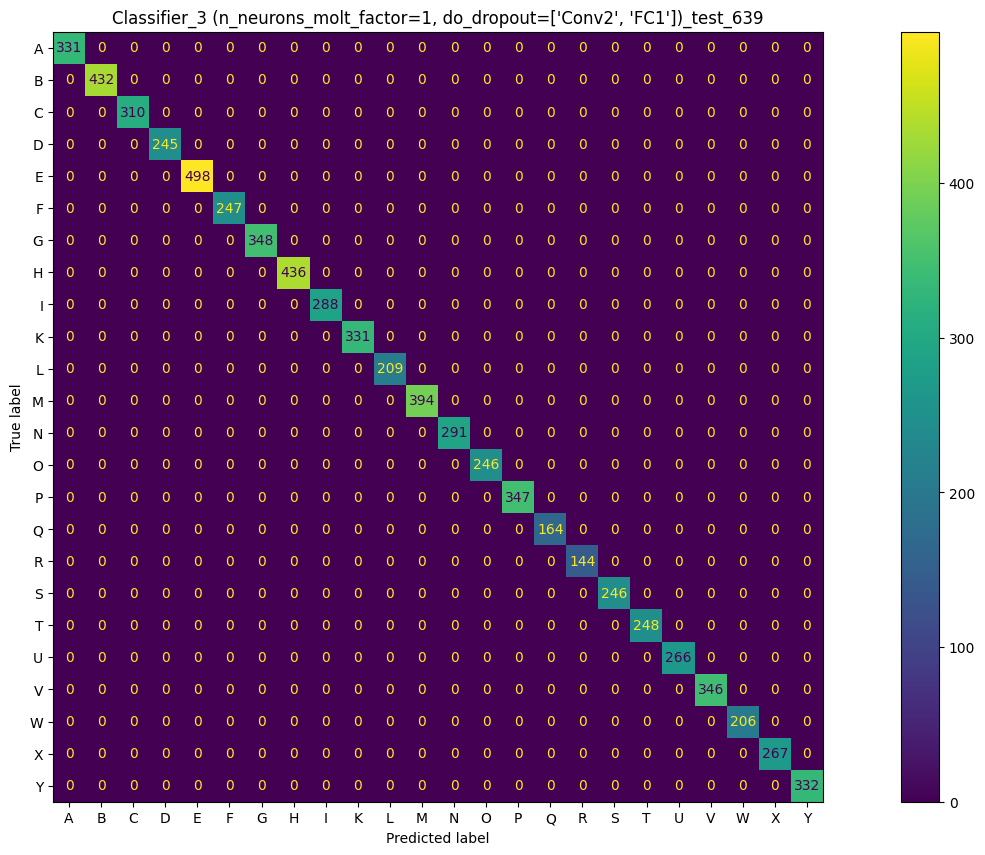

1.0
WRONG PREDICTIONS:


In [9]:
best_model = NeuralNetwork.load_NN(all_results.iloc[11101], classifiers_dict, torch.device("cuda"), (28,28))
best_model.explore_wrong_predictions()

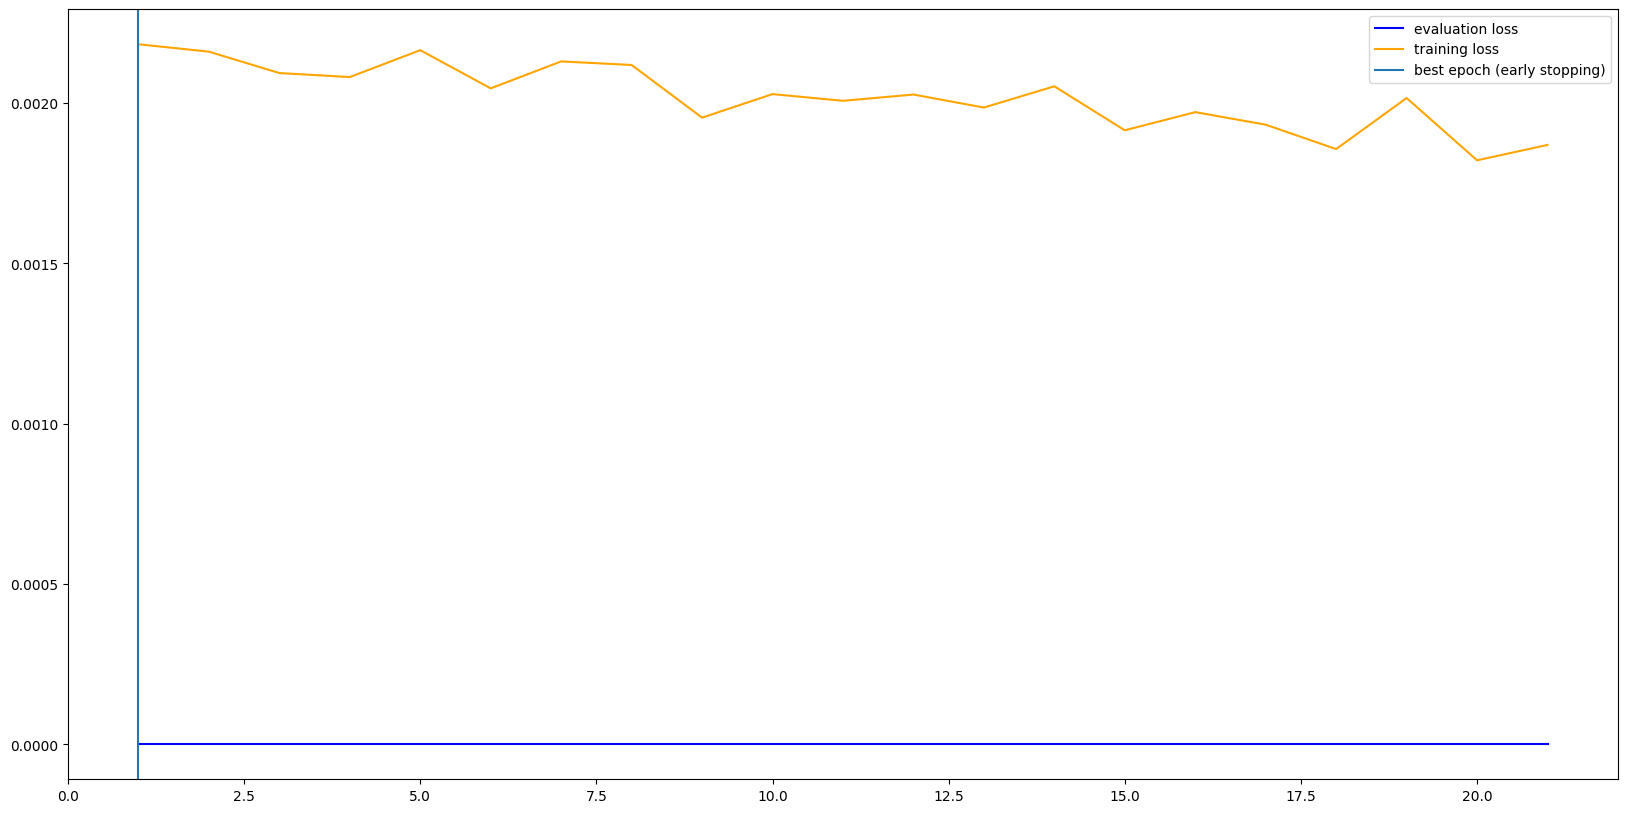

In [12]:
best_model.plot_loss()

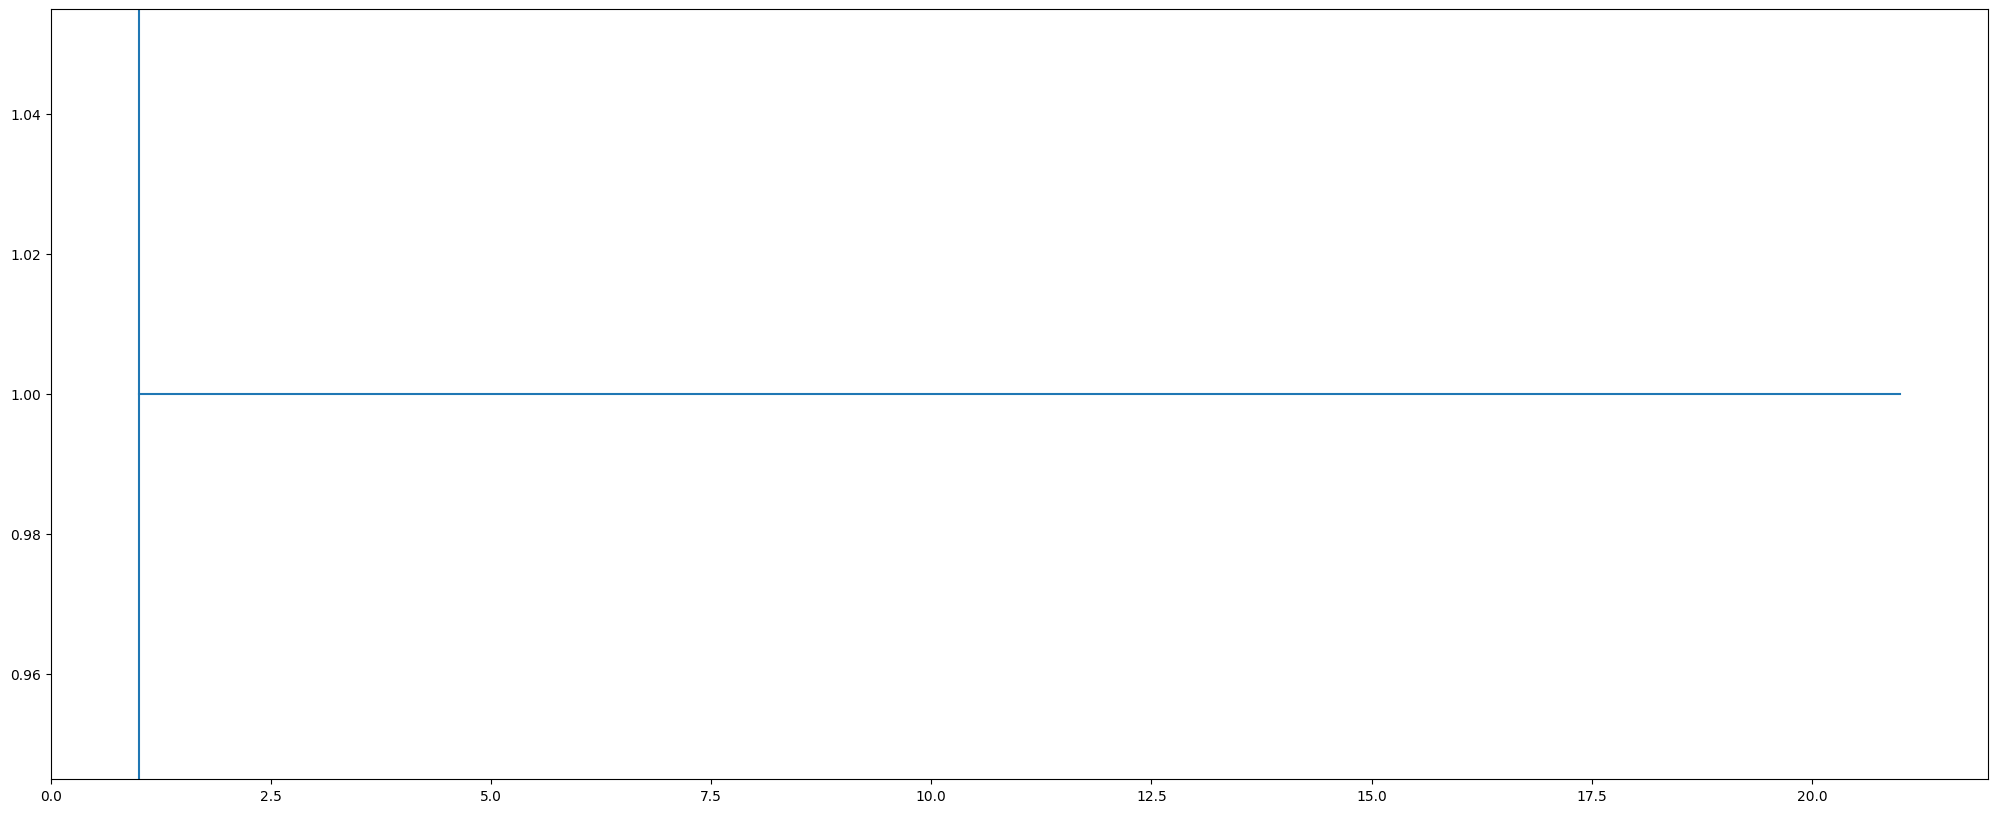

In [13]:
best_model.plot_accuracy()

In [14]:
all_results.sort_values(by=['test_accuracies'], ascending=True).head(10)

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,optimizer,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
0,0,0,2.0,['Conv2'],AMSGrad,0.00050,32,5,0.00,0.020078,0.082985,10.274774
2776,216,4,1.0,[],AMSGrad,0.00001,256,15,0.00,0.020078,0.043871,6.687428
2775,215,4,1.0,[],AMSGrad,0.00001,256,10,0.75,0.020078,0.043957,7.735766
2774,214,4,1.0,[],AMSGrad,0.00001,256,10,0.50,0.020078,0.043893,6.695827
2773,213,4,1.0,[],AMSGrad,0.00001,256,10,0.25,0.020078,0.043870,5.657037
2772,212,4,1.0,[],AMSGrad,0.00001,256,10,0.00,0.020078,0.044844,4.585186
2771,211,4,1.0,[],AMSGrad,0.00001,256,5,0.75,0.020078,0.043909,4.212966
2770,210,4,1.0,[],AMSGrad,0.00001,256,5,0.50,0.020078,0.083868,3.650336
2777,217,4,1.0,[],AMSGrad,0.00001,256,15,0.25,0.020078,0.043938,51.331028
2769,209,4,1.0,[],AMSGrad,0.00001,256,5,0.25,0.020078,0.043867,3.079880


In [15]:
n_low_accuracy_architectures = len(all_results[all_results["test_accuracies"]==all_results["test_accuracies"].min()])
n_low_accuracy_architectures

1280

In [16]:
all_results.sort_values(by=['test_accuracies'], ascending=True).head(n_low_accuracy_architectures)["architecture_id"].unique()

array([0, 4])

In [17]:
architecture_stats(all_results, classifiers_dict, 0)

Stats for architecture: Classifier_3 (n_neurons_molt_factor=2, do_dropout=['Conv2']) (id: 0)
mean accuracy: 0.0201 with standard error: 0.0000

worst accuracy: 0.0201 with hyperparameters:
test_id                           0
optimizer                   AMSGrad
lr                           0.0005
batch_size                       32
patience                          5
data_augmentation_perc          0.0
test_times                 0.082985
train_times               10.274774
Name: 0, dtype: object 

best accuracy: 0.0201 with hyperparameters:
test_id                           0
optimizer                   AMSGrad
lr                           0.0005
batch_size                       32
patience                          5
data_augmentation_perc          0.0
test_times                 0.082985
train_times               10.274774
Name: 0, dtype: object 



Loaded model: Classifier_3 (n_neurons_molt_factor=2, do_dropout=['Conv2'])_test_0


Architecture:
name: Classifier_3 (n_neurons_molt_factor=2.0, do_dropout=['Conv2'])
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 32, 12, 12]          --
|    └─Conv2d: 2-1                       [-1, 32, 24, 24]          832
|    └─MaxPool2d: 2-2                    [-1, 32, 12, 12]          --
|    └─ReLU: 2-3                         [-1, 32, 12, 12]          --
├─Sequential: 1-2                        [-1, 64, 4, 4]            --
|    └─Conv2d: 2-4                       [-1, 64, 8, 8]            51,264
|    └─MaxPool2d: 2-5                    [-1, 64, 4, 4]            --
|    └─ReLU: 2-6                         [-1, 64, 4, 4]            --
|    └─Dropout: 2-7                      [-1, 64, 4, 4]            --
├─Sequential: 1-3                        [-1, 128, 1, 1]           --
|    └─Conv2d: 2-8                       [-1, 128, 2,

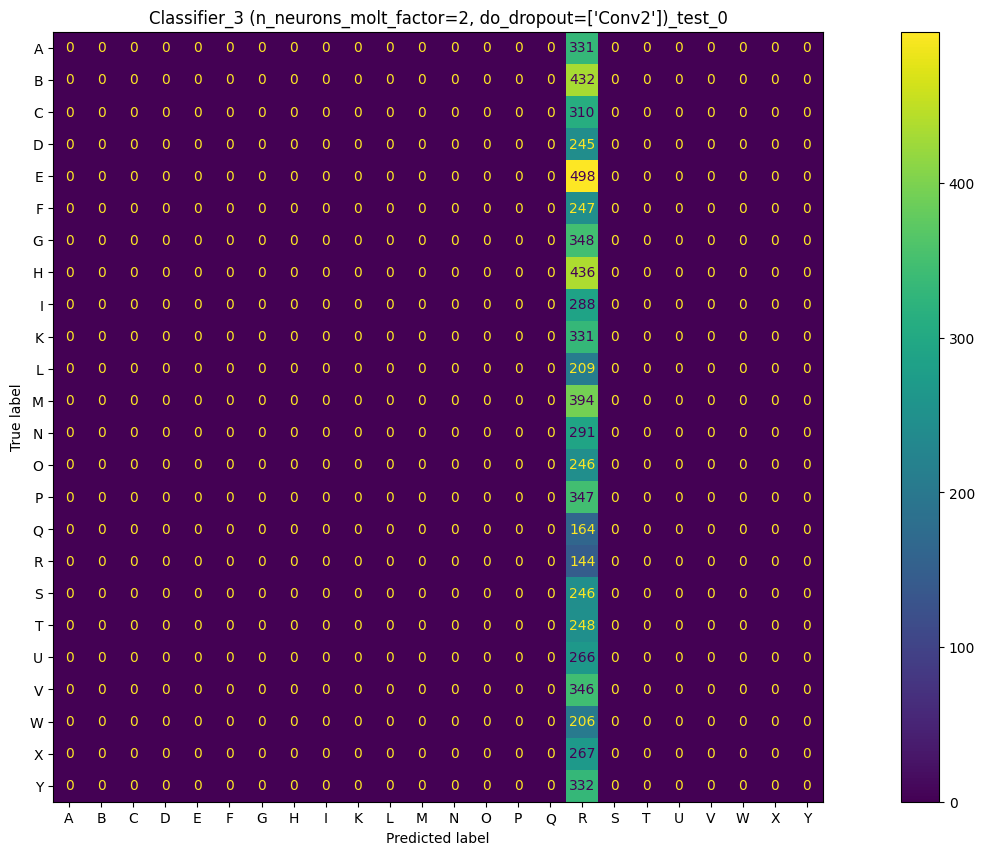

0.020078081427774678


In [18]:
NeuralNetwork.load_NN(all_results.iloc[0], classifiers_dict, torch.device("cuda"), (28,28)).plot_confusion_matrix()

In [19]:
all_results.sort_values(by=['test_accuracies'], ascending=True).iloc[320:330]

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,optimizer,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
3168,608,4,1.0,[],ADAM,0.000001,256,5,0.00,0.020078,0.043885,2.511744
2986,426,4,1.0,[],ADAM,0.000100,64,15,0.50,0.020078,0.058452,13.478697
2987,427,4,1.0,[],ADAM,0.000100,64,15,0.75,0.020078,0.058227,15.603582
2988,428,4,1.0,[],ADAM,0.000100,64,20,0.00,0.020078,0.058685,12.119834
2989,429,4,1.0,[],ADAM,0.000100,64,20,0.25,0.020078,0.058553,14.656565
2990,430,4,1.0,[],ADAM,0.000100,64,20,0.50,0.020078,0.058709,17.561255
2991,431,4,1.0,[],ADAM,0.000100,64,20,0.75,0.020078,0.058542,19.739478
2992,432,4,1.0,[],ADAM,0.000100,128,5,0.00,0.020078,0.048345,2.741736
2985,425,4,1.0,[],ADAM,0.000100,64,15,0.25,0.020078,0.058631,15.616779
2993,433,4,1.0,[],ADAM,0.000100,128,5,0.25,0.020078,0.047956,3.363183


In [18]:
model = NeuralNetwork.load_NN(all_results.iloc[2880], classifiers_dict, torch.device("cuda"), (28,28))
model.plot_confusion_matrix()

IndexError: single positional indexer is out-of-bounds

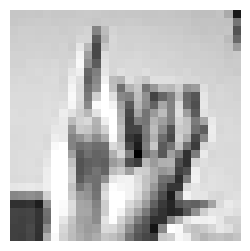

True label: I


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 1.0,
 'J': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0,
 'Y': 0.0}

In [ ]:
image, response = sample_image(index = 10)
best_model.predict(image)